## Distribución de Poisson

La distribución de Poisson es un modelo probabilístico discreto que describe el número de ocurrencias de un evento en un intervalo fijo de tiempo, espacio o cualquier otra dimensión continua, bajo ciertas condiciones ideales. Su nombre proviene del matemático francés Siméon Denis Poisson (1837).

### ¿Cuándo se aplica?

La distribución de Poisson es adecuada cuando se cumplen los siguientes supuestos (proceso de Poisson):

1. Independencia: Las ocurrencias en intervalos disjuntos son independientes entre sí.
2. Estacionariedad: La tasa media de ocurrencias ($\lambda$) es constante en el tiempo o el espacio.
3. No simultaneidad: La probabilidad de que ocurran dos o más eventos en un intervalo infinitesimal es despreciable.

### Interpretación de $\lambda$

El único parámetro de la distribución es \lambda > 0, que representa el número medio de eventos por unidad de medida.

### Función de probabilidad

$P(X = k) = \frac{e^{-\lambda} \lambda^k}{k!}, \quad k = 0,1,2,\dots$

La media y la varianza son iguales a $\lambda$:

$$
E[X] = \lambda, \qquad \text{Var}(X) = \lambda.
$$
Esta propiedad de igualdad entre media y varianza es una característica distintiva de la Poisson y a menudo se usa para verificar si los datos empíricos se ajustan a este modelo.

### Utilidad práctica

La simulación de fenómenos aleatorios que siguen una distribución de Poisson es una tarea recurrente en ingeniería, investigación de operaciones, finanzas, etc. A continuación se desarrollan los aspectos clave de su simulación, desde los algoritmos hasta su integración en modelos más amplios.

En muchos sistemas reales, el número de eventos que ocurren en un intervalo sigue una Poisson. La simulación permite:

* Estimar probabilidades de colas, tiempos de espera, niveles de inventario.
* Validar modelos analíticos cuando las suposiciones se relajan (por ejemplo, tasas no constantes).
* Generar escenarios para planes de contingencia (ej. llegadas de pacientes a urgencias).

Además, la distribución de Poisson es la base para generar procesos de Poisson (temporales o espaciales), que se simulan generando primero el número de eventos en un intervalo y luego sus instantes de ocurrencia.

#### Simulación de procesos de Poisson

Un proceso de Poisson homogéneo de tasa \lambda en un intervalo [0, T] se simula en dos pasos:

1. Número de eventos: N $\sim \text{Poisson}(\lambda T)$.
2. Instantes de ocurrencia: dados N, estos se distribuyen como uniformes independientes en [0, T].



#### Utilidad:

* Simular llegadas de clientes a un servidor.
* Generar tiempos de falla en fiabilidad (relacionado con exponencial).
* Modelar llamadas telefónicas, llegadas a una cola, etc.


#### Simulación de procesos no homogéneos

Cuando la tasa $\lambda(t)$ varía con el tiempo, se usa el método de adelgazamiento (thinning).

Se simula un proceso homogéneo con tasa máxima $\lambda_{\max}$ y luego se acepta cada evento con probabilidad $\lambda(t)/\lambda_{\max}$.

Esto permite simular fenómenos como llegadas a un centro comercial con tasas altas en horas punta.


#### Aplicaciones prácticas en simulación de sistemas

* Colas M/M/1: el número de llegadas entre dos servicios es Poisson. Simular la cola permite obtener tiempos de espera.
* Inventarios: la demanda diaria puede modelarse como Poisson. Útil para determinar puntos de reorden.
* Fiabilidad: número de fallos de un equipo en un intervalo (si son raros) → Poisson.
* Tráfico de red: el número de paquetes que llega a un enrutador por segundo.

### Conclusión

Desde el enfoque de simulación, la distribución de Poisson es un pilar fundamental. Su simulación puede ser trivial (usando librerías estándar) pero su comprensión profunda permite:

* Elegir el algoritmo adecuado según $\lambda$ y el volumen de datos.
* Simular procesos estocásticos más complejos (Poisson homogéneo/no homogéneo).
* Validar modelos y realizar análisis de sensibilidad.

Dominar estos aspectos es esencial para cualquier simulación de sistemas discretos o eventos continuos.

In [1]:
#Librerías a utilizar
import numpy as np
import random as rd
import matplotlib.pyplot as plt
from scipy import stats as st

In [2]:
#Generación de números aleatorios de una distribución de Poisson
def poisson_prng(lam, n=1):
    """
    Genera una distribución de Poisson con lambda(lam) por el 
    método de la transformada inversa
    Parameters:
    lam: float (media de la distribución de Poisson)
    n: int(Número de valores a generar)
    Returns:
    arreglo de numpy de los valores de una distribución de Poisson
    """
    result = np.zeros(n)
    for j in range(n):
        #Paso 1: Generamos números aleatorios uniformes
        U = rd.random()
        #Paso 2: Inicializamos valores
        i = 0
        p = np.exp(-lam) #p0=P(X=0)
        F = p
        #Paso 3:Chechar que U estra dentro de la distribución acumulativa hasta 0
        while U>=F: #Si fuera continuo, sería "if U<F"
            #Paso 4: Actualizar p y F al siguiente i
            p=lam*p/(i+1) #Recursión: p_{i+1}=lam/(i+1)*p_i
            i+=1
            F+=p
        #Paso 5: Ciclo de salida cuando U<F, es X=i
        result[j]=i
    return result

In [ ]:
#Valor teórico de Poisson

# Parámetros de la simulación
lam = 4.0        # media de la Poisson
n_muestras = 100 # tamaño de la muestra

# ------------------------------------------------------------
# 1. Generar las muestras (usando numpy, que es eficiente)
# ------------------------------------------------------------

muestras = poisson_prng(lam, n_muestras) 

# ------------------------------------------------------------
# 2. Calcular frecuencias observadas (empíricas)
# ------------------------------------------------------------
valores_unicos, frecuencias = np.unique(muestras, return_counts=True)
pmf_empirica = frecuencias / n_muestras

# ------------------------------------------------------------
# 3. Calcular la PMF teórica para los mismos valores (y un rango adicional)
# ------------------------------------------------------------
x_min, x_max = 0, max(valores_unicos.max(), int(lam + 4*np.sqrt(lam))) + 1
x_teorico = np.arange(x_min, x_max)
pmf_teorica = st.poisson.pmf(x_teorico, lam) 

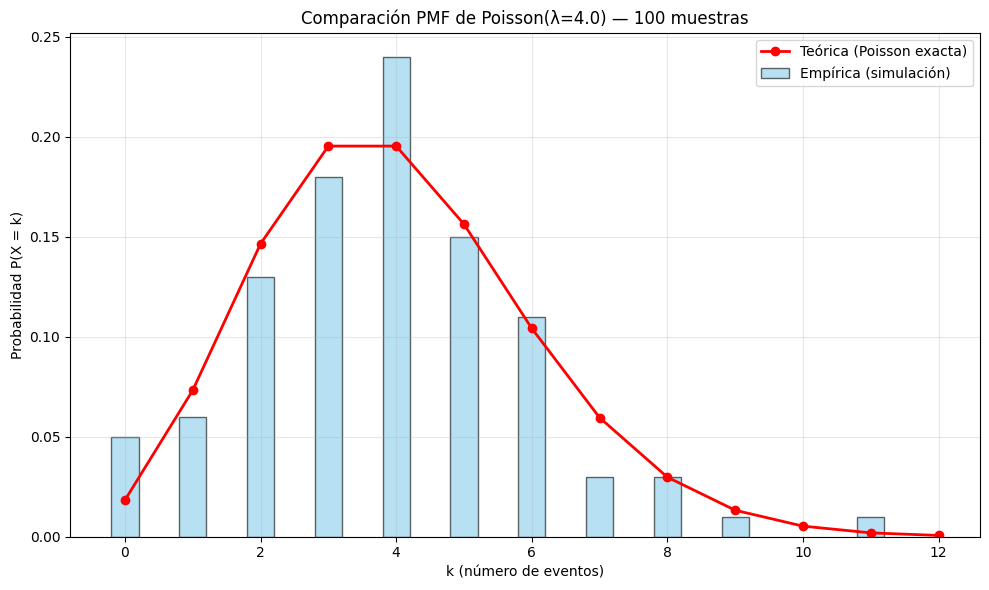

In [10]:
#Gráfica teórica y real de distribución
# ------------------------------------------------------------
# 4. Graficar ambas PMF
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

# Barras: empírica
plt.bar(valores_unicos, pmf_empirica, width=0.4, alpha=0.6, 
        label='Empírica (simulación)', color='skyblue', edgecolor='black')

# Línea/puntos: teórica
plt.plot(x_teorico, pmf_teorica, 'ro-', markersize=6, linewidth=2, 
         label='Teórica (Poisson exacta)')

plt.xlabel('k (número de eventos)')
plt.ylabel('Probabilidad P(X = k)')
plt.title(f'Comparación PMF de Poisson(λ={lam}) — {n_muestras} muestras')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()